# e-Stat データ EDA（探索的データ分析）

国勢調査メッシュ統計・経済センサスのデータ構造と分布を把握する


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")

preferred_fonts = ["MS Gothic", "IPAexGothic", "IPAGothic", "Yu Gothic"]
available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = selected_font
    print(f"日本語フォント設定: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントを使用します")
plt.rcParams["axes.unicode_minus"] = False

import config.settings as settings
from config.settings import ESTAT_API_BASE_URL, ESTAT_API_KEY
from src.collect.estat import get_stats_list, get_stats_data, fetch_mesh_population

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(filename: str) -> Path:
    path = PROCESSED_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"図を保存しました: {path}")
    return path

def build_mock_mesh_population() -> pd.DataFrame:
    return pd.DataFrame(
        {
            "tab": ["001"] * 8,
            "cat01": ["人口総数", "人口総数", "人口総数", "人口総数", "男", "男", "女", "女"],
            "area": ["53394511", "53394512", "53394521", "53394522", "53394611", "53394612", "53394621", "53394622"],
            "time": ["2020年"] * 8,
            "value": [12500, 9200, 15400, 8700, 6100, 4500, 6400, 4700],
        }
    )

def build_mock_economic_census() -> pd.DataFrame:
    return pd.DataFrame(
        {
            "area": ["13101", "13102", "13103", "14100", "27100", "23100"],
            "area_name": ["千代田区", "中央区", "港区", "横浜市", "大阪市", "名古屋市"],
            "cat01": ["飲食店", "飲食店", "持ち帰り・配達飲食サービス業", "飲食店", "各種商品小売業", "飲食店"],
            "cat02": ["事業所数", "従業者数", "事業所数", "年間商品販売額", "事業所数", "従業者数"],
            "value": [850, 21000, 420, 98000, "X", 13400],
        }
    )

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ESTAT_API_BASE_URL: {ESTAT_API_BASE_URL}")
print(f"ESTAT_API_KEY 設定状況: {'設定済み' if ESTAT_API_KEY else '未設定'}")
if not ESTAT_API_KEY:
    print("環境変数 ESTAT_API_KEY が未設定です。API 呼び出し失敗時はモックデータで継続します。")


日本語フォント設定: MS Gothic
PROJECT_ROOT: C:\Users\hisaf\.gemini\antigravity\scratch\market_gap_finder
ESTAT_API_BASE_URL: https://api.e-stat.go.jp/rest/3.0/app
ESTAT_API_KEY 設定状況: 設定済み


## Section 1 - 統計表一覧の探索


In [2]:
search_terms = ["国勢調査 メッシュ 人口", "経済センサス 飲食", "商業統計 飲食"]
stats_search_results = {}

for term in search_terms:
    print(f"\n検索中: {term}")
    try:
        result = get_stats_list(term, limit=10)
        if result.empty:
            raise ValueError("検索結果が空でした")
    except Exception as exc:
        print(f"API 取得に失敗したためモック結果を使用します: {exc}")
        result = pd.DataFrame(
            {
                "stats_id": ["0003412636", "0003441172", "0000000000"],
                "stat_name": [term, term, term],
                "title": [
                    f"{term} に関する候補統計表 1",
                    f"{term} に関する候補統計表 2",
                    f"{term} に関する候補統計表 3",
                ],
                "survey_date": ["2020", "2021", "2016"],
            }
        )
    stats_search_results[term] = result
    display(result)



検索中: 国勢調査 メッシュ 人口
API 取得に失敗したためモック結果を使用します: 検索結果が空でした


,stats_id,stat_name,title,survey_date
0,0003412636,国勢調査 メッシュ 人口,国勢調査 メッシュ 人口 に関する候補統計表 1,2020
1,0003441172,国勢調査 メッシュ 人口,国勢調査 メッシュ 人口 に関する候補統計表 2,2021
2,0000000000,国勢調査 メッシュ 人口,国勢調査 メッシュ 人口 に関する候補統計表 3,2016



検索中: 経済センサス 飲食


,stats_id,stat_name,title,survey_date
0,0000010103,社会・人口統計体系,Ｃ 経済基盤,0
1,0000010103,社会・人口統計体系,Ｃ 経済基盤,0
2,0000020103,社会・人口統計体系,Ｃ 経済基盤,0
3,0000020203,社会・人口統計体系,Ｃ 経済基盤,0
4,0003094894,経済センサス‐活動調査,飲食店及び持ち帰り・配達飲食サービス業(細分類)，経営組織(４区分)別民営事業所数，従業上の...,201202
5,0003215480,経済センサス‐活動調査,飲食店及び持ち帰り・配達飲食サービス業（細分類），経営組織（４区分）別民営事業所数，従業上の...,201606
6,0000010108,社会・人口統計体系,Ｈ 居住,0
7,0000010108,社会・人口統計体系,Ｈ 居住,0
8,0004015860,経済センサス‐活動調査,特性別、立地環境小分類（小売業・飲食サービス業・生活関連サービス業）別の事業所数、従業者数、...,202106
9,0004015880,経済センサス‐活動調査,商業集積地区（商店街）の小売業・飲食サービス業・生活関連サービス業別、都道府県別、市区町村別...,202106



検索中: 商業統計 飲食


,stats_id,stat_name,title,survey_date
0,0003014475,商業統計調査,データ(平成20年4月3日公表) 産業分類細分類別の事業所数（従業者規模別）、従業者数、年間...,200701-200712
1,0003014476,商業統計調査,データ(平成20年4月3日公表) 産業分類細分類別の法人・個人別、男女別の就業者数、従業者数...,200701-200712
2,0003014228,商業統計調査,統計表 産業分類細分類別、年次別の事業所数（法人・個人別）、従業者数、年間商品販売額、商品手...,200701-200712
3,0003014229,商業統計調査,統計表 産業分類細分類別、法人・個人別、男女別の就業者数、従業者数（内訳別）、臨時雇用者数、...,200701-200712
4,0003014232,商業統計調査,統計表 産業分類細分類別、従業者規模別の事業所数（法人・個人別）、従業者数（法人・個人別）、...,200701-200712
5,0003014233,商業統計調査,統計表 小売業の産業分類細分類別、売場面積規模別の事業所数（法人・個人別）、従業者数（法人・...,200701-200712
6,0003014235,商業統計調査,統計表 産業分類細分類別、従業者規模別、販売方法別の事業所数、年間商品販売額及び構成比 第1...,200701-200712
7,0003014238,商業統計調査,統計表 小売業の産業分類細分類別、商品販売形態別の事業所数、年間商品販売額及び構成比 第1巻...,200701-200712
8,0003014242,商業統計調査,統計表 小売業の産業分類細分類別、来客用駐車場収容台数区分別の法人・個人別の事業所数、従業者...,200701-200712
9,0003014243,商業統計調査,統計表 小売業の産業分類細分類別、従業者規模別、来客用駐車場の有無別の事業所数、従業者数、年...,200701-200712


## Section 2 - 国勢調査メッシュ統計の取得と構造確認


In [3]:
statsDataId = "0003412636"
mesh1_code = "5339"
print(f"国勢調査メッシュ統計を取得します: statsDataId={statsDataId}, cdArea={mesh1_code}")

try:
    df_mesh = get_stats_data(statsDataId, cd_area=mesh1_code, limit=50000)
    if df_mesh.empty:
        print("get_stats_data が空だったため fetch_mesh_population も確認します")
        fallback_df = fetch_mesh_population([mesh1_code], stats_data_id=statsDataId)
        print(f"fetch_mesh_population の取得件数: {len(fallback_df)}")
        raise ValueError("国勢調査メッシュ統計が空でした")
except Exception as exc:
    print(f"API 取得に失敗したためモックデータを使用します: {exc}")
    df_mesh = build_mock_mesh_population()

print("DataFrame info")
df_mesh.info()

print("\ndescribe(include='all')")
display(df_mesh.describe(include="all").T)

print("\nhead(20)")
display(df_mesh.head(20))

column_profile = pd.DataFrame(
    {
        "dtype": df_mesh.dtypes.astype(str),
        "unique_count": [df_mesh[col].nunique(dropna=False) for col in df_mesh.columns],
    },
    index=df_mesh.columns,
)
print("\nカラム一覧とユニーク値数")
display(column_profile)


国勢調査メッシュ統計を取得します: statsDataId=0003412636, cdArea=5339


メッシュ人口の取得に失敗しました: mesh_code=5339


get_stats_data が空だったため fetch_mesh_population も確認します
fetch_mesh_population の取得件数: 0
API 取得に失敗したためモックデータを使用します: 国勢調査メッシュ統計が空でした
DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tab     8 non-null      object
 1   cat01   8 non-null      object
 2   area    8 non-null      object
 3   time    8 non-null      object
 4   value   8 non-null      int64 
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes

describe(include='all')


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tab,8,1,001,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cat01,8,3,人口総数,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,8,8,53394511,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,8,1,2020年,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,8.0,NaN,NaN,NaN,8437.5,3867.792837,4500.0,5750.0,7550.0,10025.0,15400.0



head(20)


,tab,cat01,area,time,value
0,001,人口総数,53394511,2020年,12500
1,001,人口総数,53394512,2020年,9200
2,001,人口総数,53394521,2020年,15400
3,001,人口総数,53394522,2020年,8700
4,001,男,53394611,2020年,6100
5,001,男,53394612,2020年,4500
6,001,女,53394621,2020年,6400
7,001,女,53394622,2020年,4700



カラム一覧とユニーク値数


,dtype,unique_count
tab,object,1
cat01,object,3
area,object,8
time,object,1
value,int64,8


## Section 3 - 人口データの分布分析


value 列を数値変換します
有効な人口データ件数: 8 / 8


,population_stats
count,8.000000
mean,8437.500000
std,3867.792837
min,4500.000000
25%,5750.000000
50%,7550.000000
75%,10025.000000
max,15400.000000


図を保存しました: C:\Users\hisaf\.gemini\antigravity\scratch\market_gap_finder\data\processed\estat_population_distribution.png


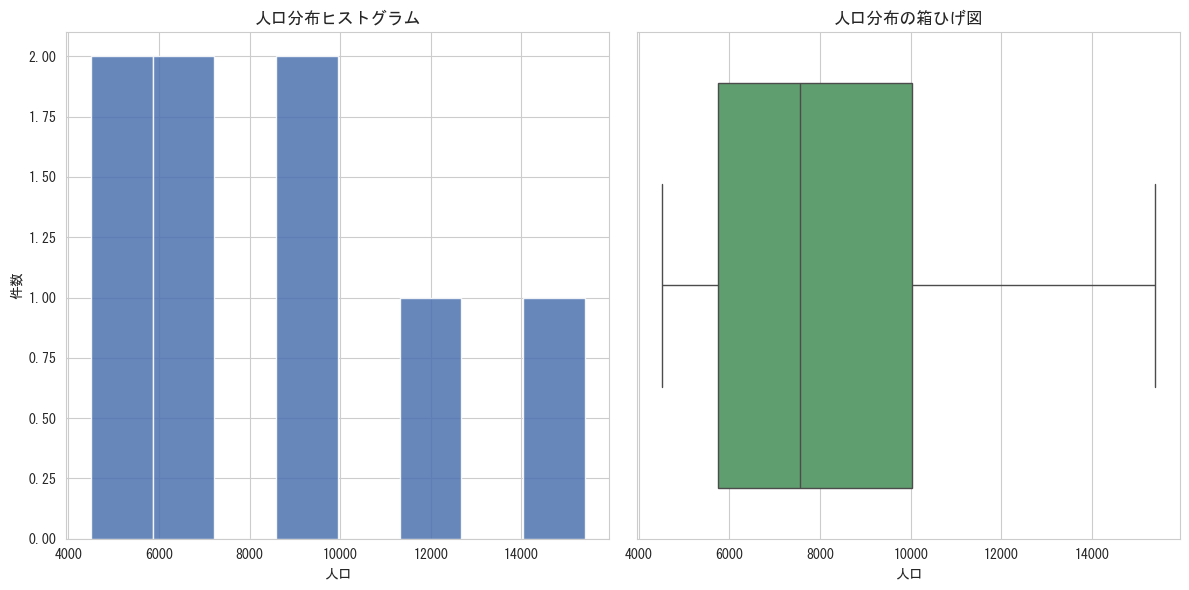

In [4]:
print("value 列を数値変換します")
df_mesh_dist = df_mesh.copy()
df_mesh_dist["value_numeric"] = pd.to_numeric(df_mesh_dist.get("value"), errors="coerce")
valid_population = df_mesh_dist["value_numeric"].dropna()

print(f"有効な人口データ件数: {len(valid_population)} / {len(df_mesh_dist)}")
display(valid_population.describe().to_frame(name="population_stats"))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].hist(valid_population, bins=min(30, max(5, len(valid_population))), color="#4C72B0", alpha=0.85)
axes[0].set_title("人口分布ヒストグラム")
axes[0].set_xlabel("人口")
axes[0].set_ylabel("件数")

sns.boxplot(x=valid_population, ax=axes[1], color="#55A868")
axes[1].set_title("人口分布の箱ひげ図")
axes[1].set_xlabel("人口")

plt.tight_layout()
save_figure("estat_population_distribution.png")
plt.show()


cat01 ごとの件数と平均値を集計します


,cat01,record_count,avg_value
0,人口総数,4,11450.0
1,女,2,5550.0
2,男,2,5300.0


図を保存しました: C:\Users\hisaf\.gemini\antigravity\scratch\market_gap_finder\data\processed\estat_population_by_cat01.png


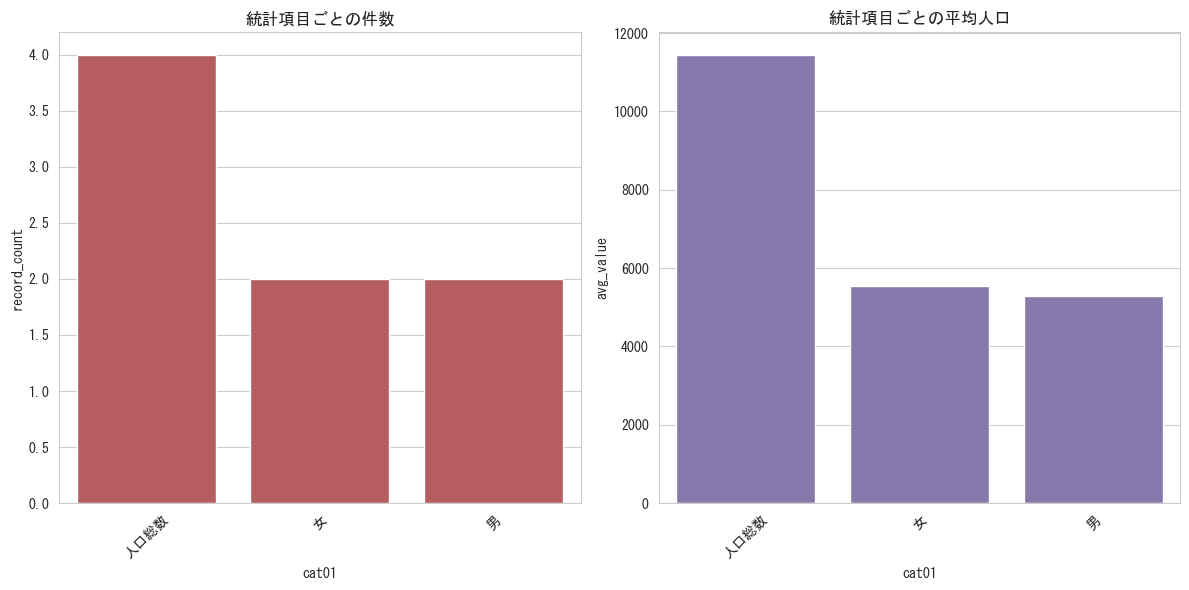

In [5]:
category_col = "cat01" if "cat01" in df_mesh_dist.columns else None
if category_col is None:
    print("cat01 列が存在しないためカテゴリ別分析をスキップします")
else:
    print(f"{category_col} ごとの件数と平均値を集計します")
    category_summary = (
        df_mesh_dist.groupby(category_col, dropna=False)
        .agg(record_count=(category_col, "size"), avg_value=("value_numeric", "mean"))
        .sort_values("record_count", ascending=False)
        .reset_index()
    )
    display(category_summary)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    sns.barplot(data=category_summary, x=category_col, y="record_count", ax=axes[0], color="#C44E52")
    axes[0].set_title("統計項目ごとの件数")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(data=category_summary, x=category_col, y="avg_value", ax=axes[1], color="#8172B3")
    axes[1].set_title("統計項目ごとの平均人口")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    save_figure("estat_population_by_cat01.png")
    plt.show()


## Section 4 - 空間分布の確認


3次メッシュコードから緯度経度へ変換します


,area,mesh_code_8,lat,lon,plot_value,cat01
0,53394511,53394511,35.679167,139.64375,12500,人口総数
1,53394512,53394512,35.679167,139.65625,9200,人口総数
2,53394521,53394521,35.687500,139.64375,15400,人口総数
3,53394522,53394522,35.687500,139.65625,8700,人口総数
4,53394611,53394611,35.679167,139.76875,6100,男
5,53394612,53394612,35.679167,139.78125,4500,男
6,53394621,53394621,35.687500,139.76875,6400,女
7,53394622,53394622,35.687500,139.78125,4700,女


図を保存しました: C:\Users\hisaf\.gemini\antigravity\scratch\market_gap_finder\data\processed\estat_population_spatial_scatter.png


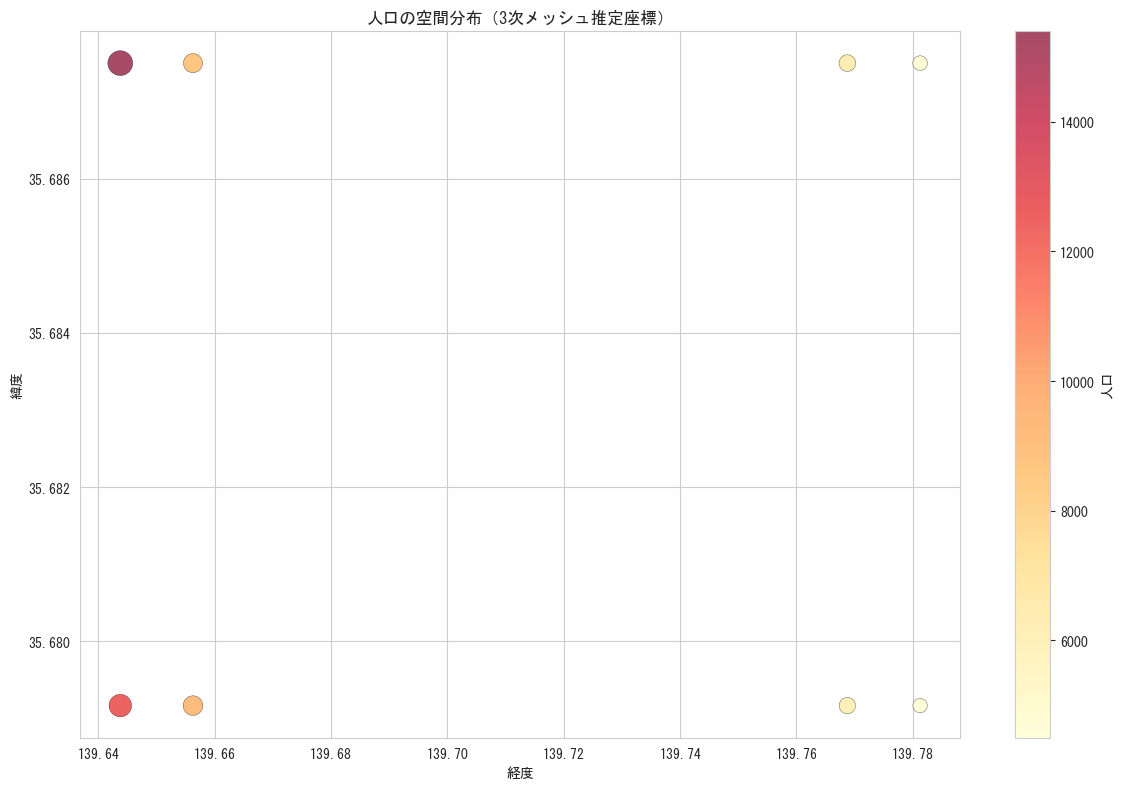

In [6]:
def mesh3_to_lat_lon(mesh_code: str) -> tuple[float, float]:
    """JIS標準3次メッシュコード（8桁）から中心の緯度経度を推定する。

    3次メッシュ: 約1km四方
    - 上2桁: 1次メッシュ緯度（×2/3度）
    - 次2桁: 1次メッシュ経度（+100度）
    - 5桁目: 2次メッシュ緯度（×5分）
    - 6桁目: 2次メッシュ経度（×7.5分）
    - 7桁目: 3次メッシュ緯度（×30秒）
    - 8桁目: 3次メッシュ経度（×45秒）
    """
    code = str(mesh_code)
    if len(code) < 8 or not code[:8].isdigit():
        return (np.nan, np.nan)

    code = code[:8]
    p = int(code[0:2])  # 1次メッシュ緯度
    u = int(code[2:4])  # 1次メッシュ経度
    q = int(code[4])    # 2次メッシュ緯度
    r = int(code[5])    # 2次メッシュ経度
    s = int(code[6])    # 3次メッシュ緯度
    t = int(code[7])    # 3次メッシュ経度

    # 南西角 + 半メッシュ分で中心座標
    lat = p / 1.5 + q * 5 / 60 + s * 30 / 3600 + 15 / 3600
    lon = u + 100 + r * 7.5 / 60 + t * 45 / 3600 + 22.5 / 3600
    return (lat, lon)

print("3次メッシュコードから緯度経度へ変換します")
df_map = df_mesh_dist.copy()

# area列からメッシュコード（8桁以上の数値）を抽出
area_col = "area" if "area" in df_map.columns else df_map.columns[df_map.columns.str.contains("area", case=False)][0] if any(df_map.columns.str.contains("area", case=False)) else None
if area_col:
    df_map["mesh_code_8"] = df_map[area_col].astype(str).str.extract(r"(\d{8})", expand=False)
else:
    df_map["mesh_code_8"] = pd.Series(dtype=str, index=df_map.index)

df_map[["lat", "lon"]] = df_map["mesh_code_8"].apply(
    lambda x: pd.Series(mesh3_to_lat_lon(x) if pd.notna(x) else (np.nan, np.nan))
)
df_map["plot_value"] = df_map["value_numeric"].fillna(0)

plot_df = df_map.dropna(subset=["lat", "lon"]).copy()
show_cols = [c for c in ["area", "mesh_code_8", "lat", "lon", "plot_value", "cat01"] if c in plot_df.columns]
display(plot_df[show_cols].head(10))

if plot_df.empty:
    print("8桁メッシュコードが見つからないため散布図を描画できません")
else:
    max_val = plot_df["plot_value"].max()
    size = np.where(
        (plot_df["plot_value"] > 0) & (max_val > 0),
        plot_df["plot_value"] / max_val * 300 + 20,
        20
    )
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        plot_df["lon"],
        plot_df["lat"],
        c=plot_df["plot_value"],
        s=size,
        cmap="YlOrRd",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
    )
    plt.title("人口の空間分布（3次メッシュ推定座標）")
    plt.xlabel("経度")
    plt.ylabel("緯度")
    plt.colorbar(scatter, label="人口")
    plt.tight_layout()
    save_figure("estat_population_spatial_scatter.png")
    plt.show()

## Section 5 - 経済センサスデータの探索


In [7]:
economic_stats_id = "0003441172"
print(f"経済センサスデータを取得します: statsDataId={economic_stats_id}")

try:
    df_econ = get_stats_data(economic_stats_id, limit=50000)
    if df_econ.empty:
        raise ValueError("経済センサスデータが空でした")
except Exception as exc:
    print(f"API 取得に失敗したためモックデータを使用します: {exc}")
    df_econ = build_mock_economic_census()

print("DataFrame info")
df_econ.info()

print("\ndescribe(include='all')")
display(df_econ.describe(include="all").T)

print("\nhead(20)")
display(df_econ.head(20))

food_mask = pd.Series(False, index=df_econ.index)
for col in ["cat01", "cat01_name", "cat02", "cat02_name", "title"]:
    if col in df_econ.columns:
        food_mask = food_mask | df_econ[col].astype(str).str.contains("飲食", na=False)

df_econ_food = df_econ.loc[food_mask].copy()
print(f"\n飲食業関連の抽出件数: {len(df_econ_food)}")
display(df_econ_food.head(20))


経済センサスデータを取得します: statsDataId=0003441172
DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tab     120 non-null    object
 1   cat01   120 non-null    object
 2   cat02   120 non-null    object
 3   time    120 non-null    object
 4   @unit   120 non-null    object
 5   value   120 non-null    object
dtypes: object(6)
memory usage: 5.8+ KB

describe(include='all')


,count,unique,top,freq
tab,120,2,当該拠出金等のある世帯数,60
cat01,120,6,拠出金,20
cat02,120,10,総数,12
time,120,1,2018年(平成30年),120
@unit,120,2,世帯数１万対,60
value,120,115,146,2



head(20)


,tab,cat01,cat02,time,@unit,value
0,当該拠出金等のある世帯数,拠出金,総数,2018年(平成30年),世帯数１万対,5971
1,当該拠出金等のある世帯数,拠出金,２９歳以下,2018年(平成30年),世帯数１万対,146
2,当該拠出金等のある世帯数,拠出金,３０～３９歳,2018年(平成30年),世帯数１万対,455
3,当該拠出金等のある世帯数,拠出金,４０～４９歳,2018年(平成30年),世帯数１万対,860
4,当該拠出金等のある世帯数,拠出金,５０～５９歳,2018年(平成30年),世帯数１万対,934
5,当該拠出金等のある世帯数,拠出金,６０～６９歳,2018年(平成30年),世帯数１万対,1412
6,当該拠出金等のある世帯数,拠出金,７０～７９歳,2018年(平成30年),世帯数１万対,1328
7,当該拠出金等のある世帯数,拠出金,８０歳以上,2018年(平成30年),世帯数１万対,836
8,当該拠出金等のある世帯数,拠出金,（再掲）６５歳以上,2018年(平成30年),世帯数１万対,3008
9,当該拠出金等のある世帯数,拠出金,（再掲）７５歳以上,2018年(平成30年),世帯数１万対,1470



飲食業関連の抽出件数: 0


,tab,cat01,cat02,time,@unit,value


## Section 6 - 欠損値・データ品質チェック


国勢調査メッシュ統計のデータ品質を確認します


,missing_rate_pct
tab,0.0
cat01,0.0
area,0.0
time,0.0
value,0.0


,metric,value,note
0,総レコード数,8.0,母数
1,秘匿値率,0.0,"value 列の '-', 'X', '***' 等の割合"
2,有効データ率,100.0,数値変換できた割合


図を保存しました: C:\Users\hisaf\.gemini\antigravity\scratch\market_gap_finder\data\processed\estat_data_quality_summary.png


C:\Users\hisaf\AppData\Local\Temp\ipykernel_20676\2276218786.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quality_summary, x="metric", y="value", palette=["#4C72B0", "#DD8452", "#55A868"])


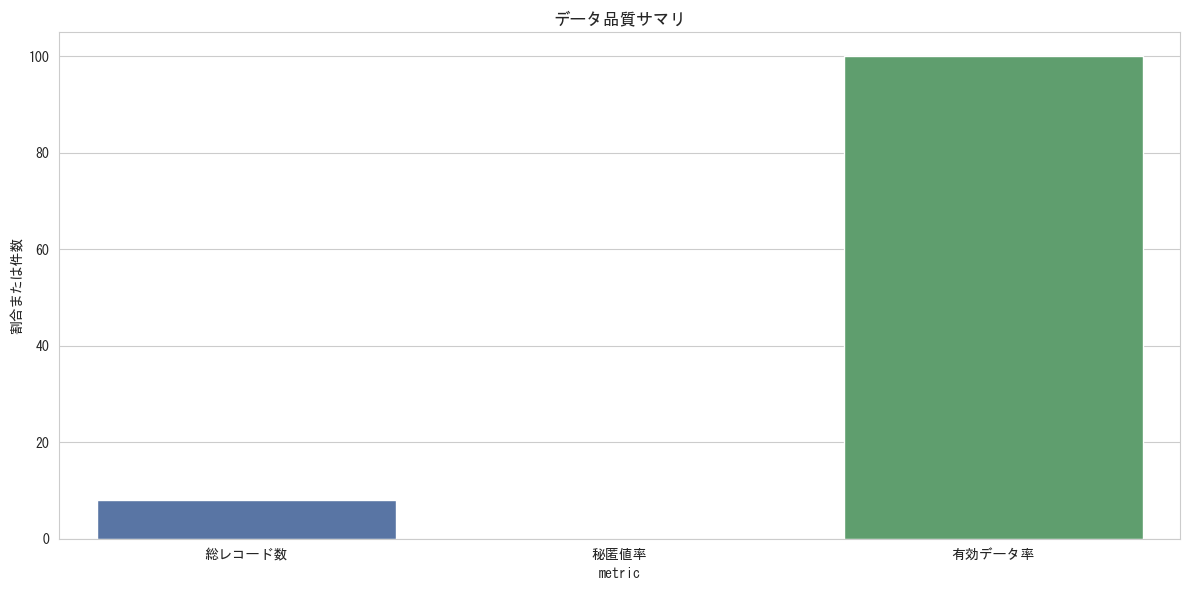

In [8]:
print("国勢調査メッシュ統計のデータ品質を確認します")
missing_rate = (df_mesh.isna().mean() * 100).sort_values(ascending=False).rename("missing_rate_pct")
display(missing_rate.to_frame())

secret_tokens = {"-", "X", "***", "…", ".."}
value_as_str = df_mesh.get("value", pd.Series(dtype=object)).astype(str)
secret_mask = value_as_str.isin(secret_tokens)
secret_ratio = secret_mask.mean() * 100 if len(value_as_str) else 0.0
valid_ratio = pd.to_numeric(df_mesh.get("value"), errors="coerce").notna().mean() * 100 if len(df_mesh) else 0.0

quality_summary = pd.DataFrame(
    {
        "metric": ["総レコード数", "秘匿値率", "有効データ率"],
        "value": [len(df_mesh), round(secret_ratio, 2), round(valid_ratio, 2)],
        "note": ["母数", "value 列の '-', 'X', '***' 等の割合", "数値変換できた割合"],
    }
)
display(quality_summary)

plt.figure(figsize=(12, 6))
sns.barplot(data=quality_summary, x="metric", y="value", palette=["#4C72B0", "#DD8452", "#55A868"])
plt.title("データ品質サマリ")
plt.ylabel("割合または件数")
plt.tight_layout()
save_figure("estat_data_quality_summary.png")
plt.show()


## Section 7 - 既存ホットペッパーデータとの突合可能性


In [9]:
print("既存の独自メッシュと e-Stat メッシュの対応関係を整理します")

mesh_comparison = pd.DataFrame(
    {
        "項目": [
            "e-Stat メッシュ",
            "既存独自メッシュ",
            "統合方針",
        ],
        "内容": [
            "JIS 標準地域メッシュ。3次メッシュは 8 桁で約 1km 四方。",
            f"緯度 {getattr(settings, 'MESH_LAT_STEP', '未定義')}、経度 {getattr(settings, 'MESH_LON_STEP', '未定義')} 刻みの独自グリッド。",
            "店舗座標を 3次メッシュへ正規化し、その後に既存スコアリング単位へ再集約するのが堅実。",
        ],
    }
)
display(mesh_comparison)

# 変換ロジック案:
# 1. HotPepper の店舗座標(lat, lon)から JIS 3次メッシュコードを算出する。
# 2. e-Stat 側の area から得た 3次メッシュコードと join する。
# 3. 既存の独自メッシュが必要なら、3次メッシュの重心座標を既存メッシュ関数へ通して再集約する。

def lat_lon_to_mesh3(lat: float, lon: float) -> str:
    lat1 = int(lat * 1.5)
    lon1 = int(lon - 100)
    lat_rem = lat - lat1 / 1.5
    lon_rem = lon - (lon1 + 100)
    lat2 = int(lat_rem * 12)
    lon2 = int(lon_rem * 8)
    lat_rem2 = lat_rem - lat2 / 12
    lon_rem2 = lon_rem - lon2 / 8
    lat3 = int(lat_rem2 * 120)
    lon3 = int(lon_rem2 * 80)
    return f"{lat1:02d}{lon1:02d}{lat2}{lon2}{lat3}{lon3}"

def lat_lon_to_custom_mesh(lat: float, lon: float) -> str:
    lat_step = getattr(settings, "MESH_LAT_STEP", 0.005)
    lon_step = getattr(settings, "MESH_LON_STEP", 0.00625)
    return f"{int(lat / lat_step)}_{int(lon / lon_step)}"

sample_points = pd.DataFrame(
    {
        "place": ["東京駅", "新宿駅", "渋谷駅"],
        "lat": [35.681236, 35.690921, 35.658034],
        "lon": [139.767125, 139.700258, 139.701636],
    }
)
sample_points["estat_mesh3"] = sample_points.apply(lambda row: lat_lon_to_mesh3(row["lat"], row["lon"]), axis=1)
sample_points["custom_mesh"] = sample_points.apply(lambda row: lat_lon_to_custom_mesh(row["lat"], row["lon"]), axis=1)
display(sample_points)


既存の独自メッシュと e-Stat メッシュの対応関係を整理します


,項目,内容
0,e-Stat メッシュ,JIS 標準地域メッシュ。3次メッシュは 8 桁で約 1km 四方。
1,既存独自メッシュ,緯度 0.005、経度 0.00625 刻みの独自グリッド。
2,統合方針,店舗座標を 3次メッシュへ正規化し、その後に既存スコアリング単位へ再集約するのが堅実。


,place,lat,lon,estat_mesh3,custom_mesh
0,東京駅,35.681236,139.767125,53394611,7136_22362
1,新宿駅,35.690921,139.700258,53394526,7138_22352
2,渋谷駅,35.658034,139.701636,53393586,7131_22352


## まとめ

- 統計表検索により、国勢調査メッシュ統計と経済センサスの候補テーブル ID を機械的に探索できることを確認した。
- 国勢調査メッシュ統計では `area`、`cat01`、`value` などが主要列になりやすく、`value` の数値化と秘匿値判定が前処理の要点になる。
- 3次メッシュコードから概算の緯度経度を復元することで、人口の空間分布を簡易に可視化できる。
- 経済センサスは飲食業関連の抽出条件を明示的に持たせる必要があり、分類列の揺れに備えたフィルタが必要になる。
- 次のステップは、HotPepper の店舗座標を JIS 標準地域メッシュへ正規化して e-Stat 指標と統合し、`scoring.py` の v2 ロジックへ投入すること。
